In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
# 加载数据
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
print("tags shape:", tags.shape)

ratings.head()

ratings shape: (100836, 4)
movies shape: (9742, 3)
tags shape: (3683, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
print(ratings.info())
print(movies.info())

# 检查缺失值
print("ratings 缺失值:\n", ratings.isnull().sum())
print("movies 缺失值:\n", movies.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
ratings 缺失值:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movies 缺失值:
 movieId    0
title      0
genres     0
dtype: int64


In [4]:
# 将 ratings 和 movies 合并，获得电影标题和类型
df = pd.merge(ratings, movies, on='movieId', how='left')

print("合并后数据形状:", df.shape)
print(df.head())

# 检查合并后是否有缺失
print("合并后缺失值:\n", df.isnull().sum())

合并后数据形状: (100836, 6)
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  
合并后缺失值:
 userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


In [5]:
# 将 timestamp 转换为日期
df['date'] = pd.to_datetime(df['timestamp'], unit='s')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# 数据标准化：将评分标准化到 0-1 范围（参考 Module 02 中的 CPU_frequency 归一化）
min_rating = df['rating'].min()
max_rating = df['rating'].max()
df['rating_normalized'] = (df['rating'] - min_rating) / (max_rating - min_rating)

print(f"评分范围: {min_rating} - {max_rating}")
print(f"标准化后范围: {df['rating_normalized'].min():.2f} - {df['rating_normalized'].max():.2f}")

评分范围: 0.5 - 5.0
标准化后范围: 0.00 - 1.00


In [6]:
# 描述性统计
# 数值列统计描述
print(df.describe())

# 包含 object 类型的统计描述
print(df.describe(include=['object']))

              userId        movieId         rating     timestamp  \
count  100836.000000  100836.000000  100836.000000  1.008360e+05   
mean      326.127564   19435.295718       3.501557  1.205946e+09   
min         1.000000       1.000000       0.500000  8.281246e+08   
25%       177.000000    1199.000000       3.000000  1.019124e+09   
50%       325.000000    2991.000000       3.500000  1.186087e+09   
75%       477.000000    8122.000000       4.000000  1.435994e+09   
max       610.000000  193609.000000       5.000000  1.537799e+09   
std       182.618491   35530.987199       1.042529  2.162610e+08   

                                date           year          month  \
count                         100836  100836.000000  100836.000000   
mean   2008-03-19 17:01:27.368469248    2007.722936       6.413811   
min              1996-03-29 18:36:55    1996.000000       1.000000   
25%              2002-04-18 09:57:46    2002.000000       4.000000   
50%              2007-08-02 20:31:02 

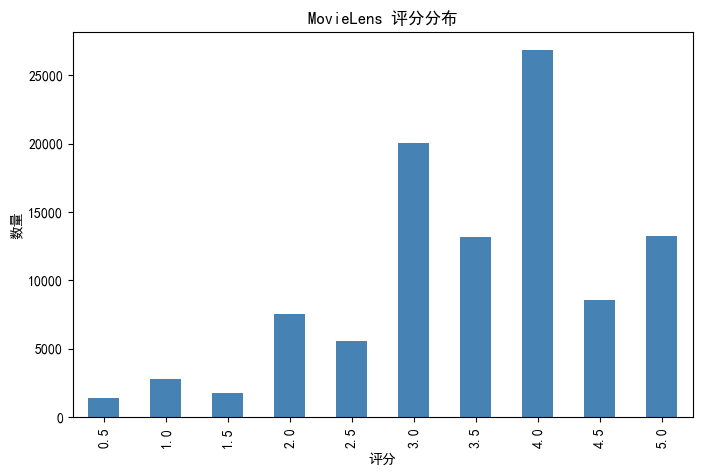

In [8]:
# 评分分布
# 指定默认字体为黑体（Windows系统通常都有）
plt.rcParams['font.sans-serif'] = ['SimHei']  
# 解决保存图像时负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False 
plt.figure(figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('MovieLens 评分分布')
plt.xlabel('评分')
plt.ylabel('数量')
plt.show()

genres
Drama          4349
Comedy         3753
Thriller       1889
Action         1828
Romance        1591
Adventure      1262
Crime          1196
Sci-Fi          980
Horror          977
Fantasy         778
Children        664
Animation       610
Mystery         573
Documentary     438
War             381
Name: count, dtype: int64


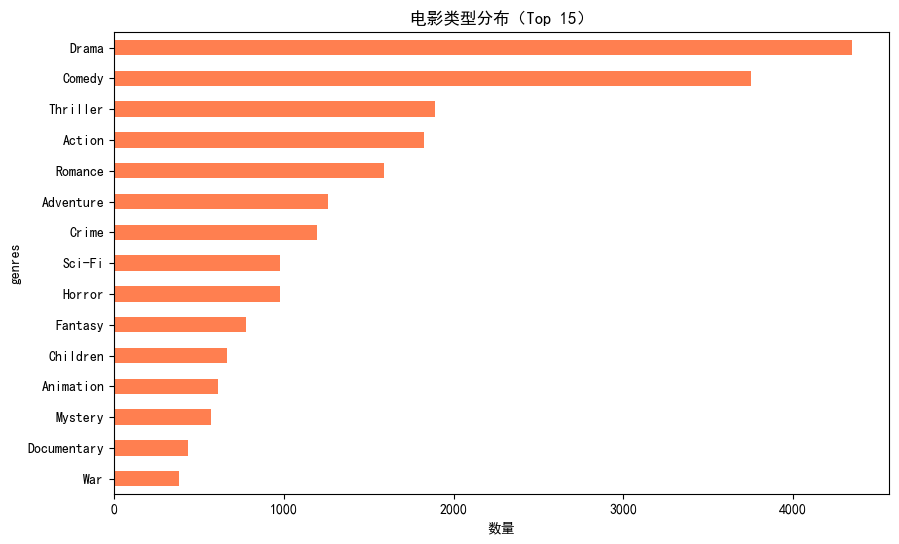

In [9]:
# 电影类型分析
# 拆分 genres 列（用 | 分隔）
genre_df = df[['movieId', 'genres']].drop_duplicates()
genre_df = genre_df.assign(genres=genre_df['genres'].str.split('|')).explode('genres')

# 各类型电影数量
genre_counts = genre_df['genres'].value_counts()
print(genre_counts.head(15))

plt.figure(figsize=(10, 6))
genre_counts.head(15).plot(kind='barh', color='coral')
plt.title('电影类型分布（Top 15）')
plt.xlabel('数量')
plt.gca().invert_yaxis()
plt.show()

                 mean  count
genres                      
Film-Noir    3.920115    870
War          3.808294   4859
Documentary  3.797785   1219
Crime        3.658294  16681
Drama        3.656184  41928
Mystery      3.632460   7674
Animation    3.629937   6988
IMAX         3.618335   4145
Western      3.583938   1930
Musical      3.563678   4138
Adventure    3.508609  24161
Romance      3.506511  18124
Thriller     3.493706  26452
Fantasy      3.491001  11834
Sci-Fi       3.455721  17243


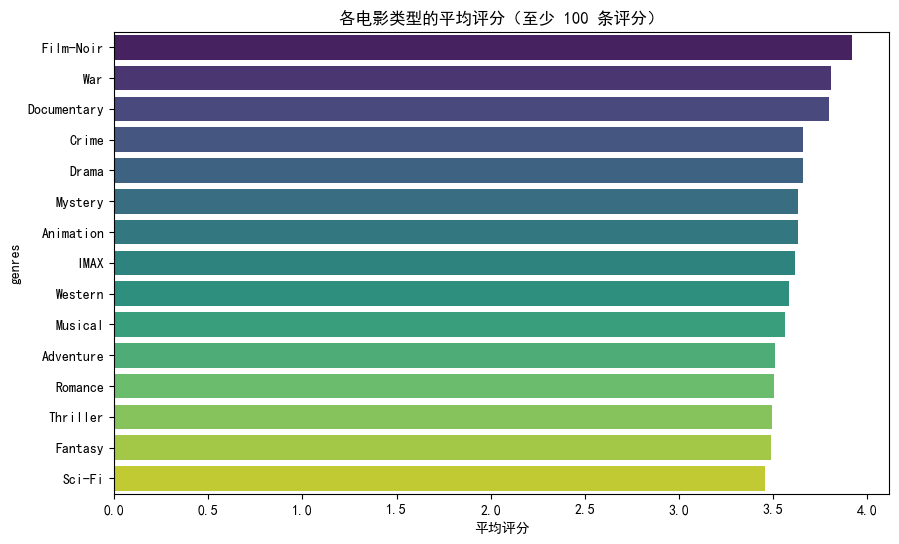

In [11]:
# 各类型电影的平均评分
# 在 df 上直接展开 genres 列（用 | 分隔）
df_genre = df[['movieId', 'rating', 'genres', 'title']].copy()
df_genre = df_genre.assign(genres=df_genre['genres'].str.split('|')).explode('genres')

# 各类型平均评分
genre_rating = df_genre.groupby('genres')['rating'].agg(['mean', 'count'])
genre_rating = genre_rating[genre_rating['count'] >= 100].sort_values('mean', ascending=False)

print(genre_rating.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_rating.head(15)['mean'],
            y=genre_rating.head(15).index, palette='viridis')
plt.title('各电影类型的平均评分（至少 100 条评分）')
plt.xlabel('平均评分')
plt.show()

                     rating  rating_normalized      year
rating             1.000000           1.000000 -0.007314
rating_normalized  1.000000           1.000000 -0.007314
year              -0.007314          -0.007314  1.000000


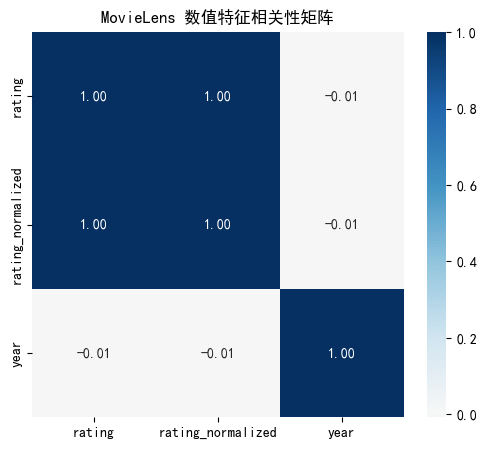

In [12]:
# 相关性分析
# 数值特征相关性
numeric_cols = ['rating', 'rating_normalized', 'year']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('MovieLens 数值特征相关性矩阵')
plt.show()

    year    rating  rating_count
13  2009  3.392496          4158
14  2010  3.463494          2301
15  2011  3.784024          1690
16  2012  3.641323          4656
17  2013  3.877404          1664
18  2014  3.510771          1439
19  2015  3.513830          6616
20  2016  3.686334          6703
21  2017  3.348805          8198
22  2018  3.389062          6418


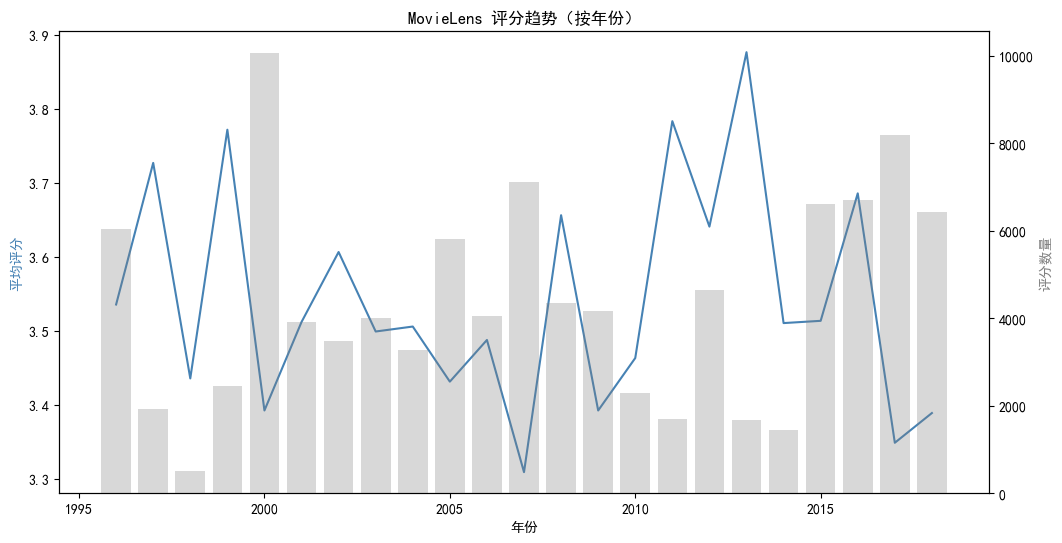

In [13]:
# 评分趋势与分组分析
# 按年份分组，观察评分趋势（参考 Module 03 中的 groupby 和 pivot table）
yearly_rating = df.groupby('year').agg({
    'rating': 'mean',
    'movieId': 'count'
}).rename(columns={'movieId': 'rating_count'}).reset_index()

print(yearly_rating.tail(10))

# 双轴折线图：评分均值 vs 评分数量
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(yearly_rating['year'], yearly_rating['rating'],
         color='steelblue', label='平均评分')
ax1.set_xlabel('年份')
ax1.set_ylabel('平均评分', color='steelblue')

ax2 = ax1.twinx()
ax2.bar(yearly_rating['year'], yearly_rating['rating_count'],
        alpha=0.3, color='gray', label='评分数量')
ax2.set_ylabel('评分数量', color='gray')

plt.title('MovieLens 评分趋势（按年份）')
plt.show()

In [14]:
# 电影热度分析
# 评分数量最多的电影
top_movies = df.groupby('title')['rating'].agg(['mean', 'count'])
top_movies = top_movies[top_movies['count'] >= 50].sort_values('count', ascending=False)

print("评分数量最多的电影（Top 10）:")
print(top_movies.head(10))

# 评分最高的电影
top_rated = df.groupby('title')['rating'].agg(['mean', 'count'])
top_rated = top_rated[top_rated['count'] >= 50].sort_values('mean', ascending=False)

print("\n评分最高的电影（Top 10，至少 50 条评分）:")
print(top_rated.head(10))

评分数量最多的电影（Top 10）:
                                               mean  count
title                                                     
Forrest Gump (1994)                        4.164134    329
Shawshank Redemption, The (1994)           4.429022    317
Pulp Fiction (1994)                        4.197068    307
Silence of the Lambs, The (1991)           4.161290    279
Matrix, The (1999)                         4.192446    278
Star Wars: Episode IV - A New Hope (1977)  4.231076    251
Jurassic Park (1993)                       3.750000    238
Braveheart (1995)                          4.031646    237
Terminator 2: Judgment Day (1991)          3.970982    224
Schindler's List (1993)                    4.225000    220

评分最高的电影（Top 10，至少 50 条评分）:
                                                        mean  count
title                                                              
Shawshank Redemption, The (1994)                    4.429022    317
Godfather, The (1972)                    

In [15]:
# Pearson 相关系数与 p 值
# 评分数量与平均评分的相关性
for param in ['rating']:
    pearson_coef, p_value = stats.pearsonr(df['rating'], df['rating_normalized'])
    print(f"{param} 与标准化评分的 Pearson r = {pearson_coef:.4f}, p = {p_value:.2e}")

# 用户评分数量与平均评分的关系
user_stats = df.groupby('userId')['rating'].agg(['mean', 'count'])
pearson_coef, p_value = stats.pearsonr(user_stats['count'], user_stats['mean'])
print(f"用户评分数量与平均评分: r = {pearson_coef:.4f}, p = {p_value:.2e}")

rating 与标准化评分的 Pearson r = 1.0000, p = 0.00e+00
用户评分数量与平均评分: r = -0.1990, p = 7.25e-07


In [16]:
# 创建用户-电影评分矩阵
rating_matrix = df.pivot_table(
    index='userId', columns='movieId', values='rating'
)
print("评分矩阵形状:", rating_matrix.shape)
print("稀疏度:", 1 - rating_matrix.notna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1]))

评分矩阵形状: (610, 9724)
稀疏度: 0.9830003169443864


In [17]:
# 基于物品的协同过滤（Item-Based CF）
# 选择一部目标电影（例如 Toy Story）
target_movie = df[df['title'].str.contains('Toy Story', case=False, na=False)]['movieId'].iloc[0]
print(f"目标电影 ID: {target_movie}")

# 计算电影间相关性
target_ratings = rating_matrix[target_movie]
correlations = rating_matrix.corrwith(target_ratings)
corr_df = pd.DataFrame(correlations, columns=['Correlation'])
corr_df = corr_df.dropna()

# 结合电影名称
corr_df = corr_df.join(movies.set_index('movieId')['title'])

# 筛选评分数量 >= 50 的电影
rating_counts = df.groupby('movieId')['rating'].count()
corr_df = corr_df.join(rating_counts.rename('rating_count'))
corr_df = corr_df[corr_df['rating_count'] >= 50]

# 推荐最相关的 10 部电影
print("\n与 Toy Story 最相似的电影（Item-Based CF）:")
print(corr_df.sort_values('Correlation', ascending=False).head(10))

目标电影 ID: 1

与 Toy Story 最相似的电影（Item-Based CF）:
         Correlation                                        title  \
movieId                                                             
1           1.000000                             Toy Story (1995)   
3114        0.699211                           Toy Story 2 (1999)   
2699        0.652424                         Arachnophobia (1990)   
8961        0.643301                      Incredibles, The (2004)   
6377        0.618701                          Finding Nemo (2003)   
588         0.611892                               Aladdin (1992)   
3408        0.598016                       Erin Brockovich (2000)   
1148        0.589625  Wallace & Gromit: The Wrong Trousers (1993)   
3671        0.585892                       Blazing Saddles (1974)   
106782      0.578479              Wolf of Wall Street, The (2013)   

         rating_count  
movieId                
1                 215  
3114               97  
2699               53  
8961

In [18]:
# 基于内容的推荐（Content-Based）
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 用 genres 作为内容特征
movies['genres_str'] = movies['genres'].str.replace('|', ' ')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_str'])

# 计算余弦相似度
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 推荐函数
def recommend_by_genre(title, cosine_sim=cosine_sim, movies=movies, top_n=10):
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

print("基于内容的推荐（Toy Story）:")
print(recommend_by_genre('Toy Story (1995)'))

基于内容的推荐（Toy Story）:
1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: object


In [19]:
# 简单评分预测模型
# 特征：用户评分数量、电影评分数量
user_rating_count = df.groupby('userId')['rating'].count().rename('user_rating_count')
movie_rating_count = df.groupby('movieId')['rating'].count().rename('movie_rating_count')

df_model = df.join(user_rating_count, on='userId')
df_model = df_model.join(movie_rating_count, on='movieId')

X = df_model[['user_rating_count', 'movie_rating_count']]
Y = df_model['rating']

# 单变量线性回归（电影评分数量）
lm = LinearRegression()
lm.fit(X[['movie_rating_count']], Y)
Yhat_slr = lm.predict(X[['movie_rating_count']])

print('单变量线性回归 R²:', lm.score(X[['movie_rating_count']], Y))
print('单变量线性回归 MSE:', mean_squared_error(Y, Yhat_slr))

# 多变量线性回归
lm1 = LinearRegression()
lm1.fit(X, Y)
Y_hat_mlr = lm1.predict(X)

print('\n多变量线性回归 R²:', lm1.score(X, Y))
print('多变量线性回归 MSE:', mean_squared_error(Y, Y_hat_mlr))

单变量线性回归 R²: 0.04729278624409328
单变量线性回归 MSE: 1.0354559666398562

多变量线性回归 R²: 0.060647532416222005
多变量线性回归 MSE: 1.0209412748150974


In [20]:
# 训练/测试集划分与模型评估
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge

# 划分训练集和测试集（10% 测试）
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.10, random_state=1
)
print("测试集样本数:", X_test.shape[0])
print("训练集样本数:", X_train.shape[0])

# 多变量线性回归
lm_eval = LinearRegression()
lm_eval.fit(X_train, Y_train)
print("\n测试集 R²:", lm_eval.score(X_test, Y_test))
print("训练集 R²:", lm_eval.score(X_train, Y_train))

# 4 折交叉验证
Rcross = cross_val_score(lm_eval, X_train, Y_train, cv=4)
print("交叉验证均值 R²:", Rcross.mean(), "标准差:", Rcross.std())

# Ridge 回归
RidgeModel = Ridge(alpha=1.0)
RidgeModel.fit(X_train, Y_train)
print("\nRidge 回归测试集 R²:", RidgeModel.score(X_test, Y_test))

测试集样本数: 10084
训练集样本数: 90752

测试集 R²: 0.05643982290648253
训练集 R²: 0.06110678884226972
交叉验证均值 R²: 0.06105429987474392 标准差: 0.0021734866499082215

Ridge 回归测试集 R²: 0.05643982290236638


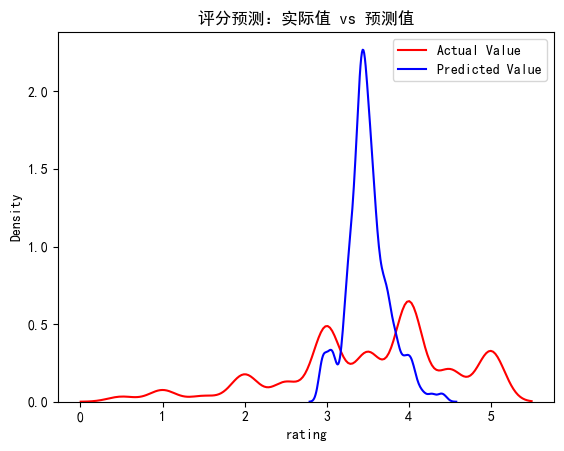

In [21]:
# 分布对比图
ax1 = sns.distplot(Y_test, hist=False, color="r", label="Actual Value")
sns.distplot(lm_eval.predict(X_test), hist=False, color="b",
             label="Fitted Values", ax=ax1)
plt.title('评分预测：实际值 vs 预测值')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()